<a href="https://colab.research.google.com/github/sedatoner/wine-knn-classifier/blob/main/knn_classifier_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

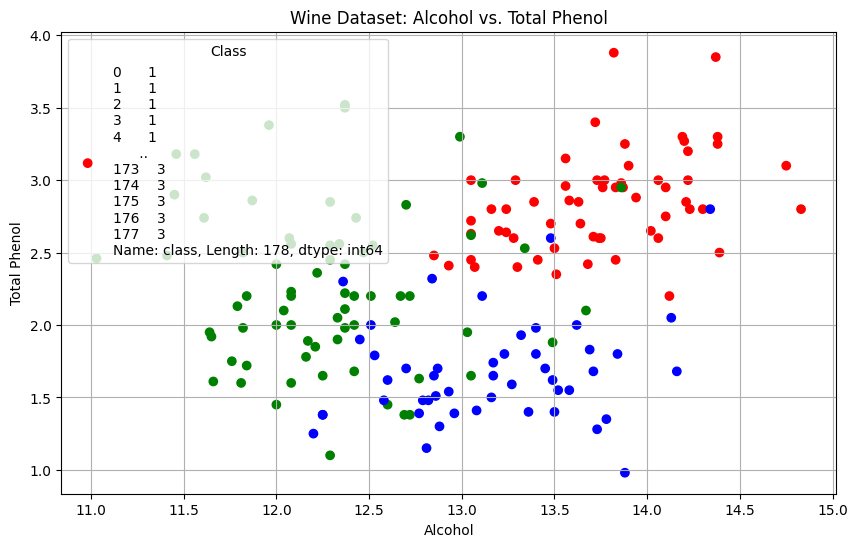

Alcohol                         0
Malicacid                       0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
0D280_0D315_of_diluted_wines    0
Proline                         0
dtype: int64


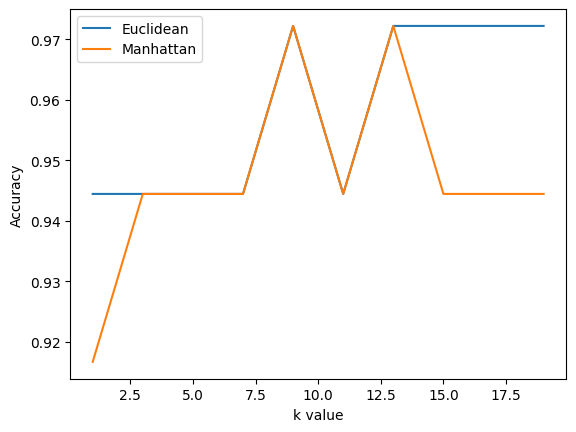

Confusion Matrix:
 [[14  0  0]
 [ 1 12  1]
 [ 0  0  8]]

Classification Report:
               precision    recall  f1-score   support

           1       0.93      1.00      0.97        14
           2       1.00      0.86      0.92        14
           3       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36



In [3]:
#libraries
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
#dataset
wine = fetch_ucirepo(id=109)
X = wine.data.features #feature matrix (independent variables)
y = wine.data.targets #target vector (dependent variable - wine classes)
#dataset disp.
print(wine.metadata, wine.variables, sep='\n')
print(X.head()) #Show first 5 feature vectors
print(y.head()) #Show first 5 target values
#relationship btw alcol and fenol
plt.figure(figsize=(10, 6))
colors = {1: 'red', 2: 'green', 3: 'blue'}  #class's colors
plt.scatter(X['Alcohol'], X['Total_phenols'], c=y['class'].map(colors), label=y['class'])
plt.grid(True)  ; plt.legend(title='Class')
#x-y label
plt.xlabel('Alcohol') ; plt.ylabel('Total Phenol')
plt.title('Wine Dataset: Alcohol vs. Total Phenol')  ; plt.show()
print(X.isnull().sum())
#normalize
scaler = MinMaxScaler()
scaled_wine_features = scaler.fit_transform(X)
#dataset train %80 test %20 sets with fixed random state for reproducibility
egitim_verileri, test_verisi, hedef_degerler, tahmin_karsilastirma = train_test_split(scaled_wine_features, y, test_size=0.2, random_state=42)
#distance
#Calculate Euclidean distance btw vectors
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))
#Calculate Manhattan distance btw vectors
def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))
#knn implement
class KNN:
  def __init__(self, k=3, distance_metric=euclidean_distance):
    self.k = k
    self.distance_metric = distance_metric  #distance calculate
  def fit(self, X, y):
    self.egitim_verileri = X  #training features
    self.hedef_degerler = y  #training labels
  def predict(self, X):
    predictions = [self._predict(x) for x in X]  #predict each sample
    return np.array(predictions)  #return as numpy array
  def _predict(self, x):
    distances = [self.distance_metric(x, x_train) for x_train in self.egitim_verileri] #calculate distance
    komsu_indeksleri = np.argsort(distances)[:self.k] #indice of knn
    k_nearest_labels = [self.hedef_degerler.iloc[i].values[0] for i in komsu_indeksleri] #labels of neighbors
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]
#evaluate model with diffrnt k value
ks = list(range(1, 20, 2)) ; accuracies_euclidean = []  ; accuracies_manhattan = []
#testing different k values for both distance metrics
for k in ks:
    #Euclidean knn
    knn = KNN(k=k, distance_metric=euclidean_distance)
    knn.fit(egitim_verileri, hedef_degerler)
    modelin_tahminleri = knn.predict(test_verisi) ; model_accuracy = accuracy_score(tahmin_karsilastirma, modelin_tahminleri)
    accuracies_euclidean.append(model_accuracy)
    #Manhattan knn
    knn = KNN(k=k, distance_metric=manhattan_distance)
    knn.fit(egitim_verileri, hedef_degerler)
    modelin_tahminleri = knn.predict(test_verisi) ; model_accuracy = accuracy_score(tahmin_karsilastirma, modelin_tahminleri)
    accuracies_manhattan.append(model_accuracy)
#accuracy comparison at various k values , distance results
plt.plot(ks, accuracies_euclidean, label='Euclidean')
plt.plot(ks, accuracies_manhattan, label='Manhattan')
#x-y label
plt.xlabel('k value');plt.ylabel('Accuracy')
plt.legend() ; plt.show()
#final
knn = KNN(k=3, distance_metric=euclidean_distance)
knn.fit(egitim_verileri, hedef_degerler)
modelin_tahminleri = knn.predict(test_verisi)
#metrics
print("Confusion Matrix:\n", confusion_matrix(tahmin_karsilastirma, modelin_tahminleri))  ;print("\nClassification Report:\n", classification_report(tahmin_karsilastirma, modelin_tahminleri))